## **Датасет**
https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset?resource=download

в датасете собраны анализы пациентов с циррозом печени, есть пустые поля и достаточно большой разброс данных, но об этом дальше

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Загрузим датасет и посмотрим на его начало и конец.

In [2]:
df = pd.read_csv("cirrhosis.csv")
pd.set_option('display.width', 10000)
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
df.tail()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0
417,418,976,C,NaN,19358,F,NaN,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,NaN,350.0,10.6,4.0


In [4]:
df.shape

(418, 20)

 Уже видно, что в датасете есть NaNы, при чём довольно много. Изучаем датасет дальше.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    str    
 3   Drug           312 non-null    str    
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    str    
 6   Ascites        312 non-null    str    
 7   Hepatomegaly   312 non-null    str    
 8   Spiders        312 non-null    str    
 9   Edema          418 non-null    str    
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombin    416 no

Видим, что в датасетике 20 колонок типов str, float и int. 
Очень много Null'ов! особенно в колонках Cholesterol, Tryglicerides, Copper, Alk_Phos, SGOT.

Сразу дропнул колонку ID, она нам не нужна и будет только мешать.

In [6]:
df.drop(columns=['ID'], inplace=True)

In [7]:
df.describe()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [8]:
df.describe(include = 'str')

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
count,418,312,418,312,312,312,418
unique,3,2,2,2,2,2,3
top,C,D-penicillamine,F,N,Y,N,N
freq,232,158,374,288,160,222,354


Видим следующее:
1. в данных достаточно большой разброс
2. на многих колонках видно скос вправо, особенно сильный у Bilirubin, Alk_phos
3. стадия заболевания указана int'ом. Это плохо, надо сделать эту колонку категорией.
Как раз с категории и начнём.

In [9]:
df['Stage'] = df['Stage'].astype('category')
df.describe(include = 'category')

,Stage
count,412.0
unique,4.0
top,3.0
freq,155.0


теперь перед тем, как визуализировать данные, поправим их. Для этого заполним NaN'ы.

Начнём с категорий.
Для Drug использую моду (D-penicillamine), тк пропусков очень много (почти четверть данных), так что выкинуть их нельзя. поэтому заполняем самым популярным значением.
Но если пропуски были бы НЕ случайными, нужно было бы заполнить пропуски соответствующей категорией (Unknown):
> `df['Drug'].fillna('Unknown', inplace=True)`
но предположим, что пропуски данных ошибочные, и просто дозаполним их модой.


In [10]:
cols_to_fill = ['Drug','Ascites', 'Hepatomegaly', 'Spiders', 'Stage']
for col in cols_to_fill:
    df.fillna({col: df[col].mode()[0]}, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   N_Days         418 non-null    int64   
 1   Status         418 non-null    str     
 2   Drug           418 non-null    str     
 3   Age            418 non-null    int64   
 4   Sex            418 non-null    str     
 5   Ascites        418 non-null    str     
 6   Hepatomegaly   418 non-null    str     
 7   Spiders        418 non-null    str     
 8   Edema          418 non-null    str     
 9   Bilirubin      418 non-null    float64 
 10  Cholesterol    284 non-null    float64 
 11  Albumin        418 non-null    float64 
 12  Copper         310 non-null    float64 
 13  Alk_Phos       312 non-null    float64 
 14  SGOT           312 non-null    float64 
 15  Tryglicerides  282 non-null    float64 
 16  Platelets      407 non-null    float64 
 17  Prothrombin    416 non-null    float64 
 18  S

Круто, наны ушли! теперь то же самое надо сделать с биохимическими float'ами вот тут мода будет плохим выбором, так как значения могут быть совершенно разными. лучше взять медиану. Мода плох из-за того, что по факту ничего не означает в нашем случае. Дубль может встретиться как у неизлечимо больного, так и у человека на первой стадии или просто здорового. Поэтому медиана на мой взгляд - лучшее решение.

In [11]:
cols_to_fill = ['Cholesterol','Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
for col in cols_to_fill:
    df.fillna({col: df[col].median()}, inplace=True)

Проверяем, что nan'ов не осталось

In [12]:
df.isna().sum()

N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

In [13]:
df.select_dtypes(include=[np.number]).agg(['min', 'max', 'mean', 'median', 'std', 'skew', 'kurtosis', 'var'])

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
min,4.100000e+01,9.598000e+03,0.300000,120.000000,1.960000,4.000000,2.890000e+02,26.350000,33.000000,62.000000,9.000000
max,4.795000e+03,2.865000e+04,28.000000,1775.000000,4.640000,588.000000,1.386240e+04,457.250000,598.000000,721.000000,18.000000
mean,1.917782e+03,1.853335e+04,3.220813,350.272727,3.497440,91.279904,1.799145e+03,120.564067,119.267943,256.866029,10.731100
median,1.730000e+03,1.862800e+04,1.400000,309.500000,3.530000,73.000000,1.259000e+03,114.700000,108.000000,251.000000,10.600000
std,1.104673e+03,3.815845e+03,4.407506,193.123893,0.424972,74.485481,1.875122e+03,49.085094,54.050691,97.024861,1.019587
skew,4.726021e-01,8.685016e-02,2.717611,4.289884,-0.467527,2.836711,3.595532e+00,1.784519,3.265724,0.640278,2.230162
kurtosis,-4.821388e-01,-6.167301e-01,8.065336,23.006923,0.566745,11.625732,1.433740e+01,6.961061,19.198908,0.970768,10.106395
var,1.220302e+06,1.456067e+07,19.426113,37296.837911,0.180601,5548.086933,3.516082e+06,2409.346446,2921.477195,9413.823735,1.039558


### **Что мы видим?**
- видим очень сильную асимметрию у многих колонок. чемпион - холестерин со своим 4.3 - график будет горбатиться влево
- эксцесс тоже огромный, рекордсмен всё тот же - холестерин. Также эксцесс большой у билирубина и меди. (значит, горб у графика будет очень высоким и острым)
- дисперсия большая у холестерина и меди - числа очень разные (точки лежат далеко от среднего)
### **О чём это говорит?**
в датасете данные пациентов с последними стадиями болезни смешаны с идеально (или почти) здоровыми людьми. из-за этого появляются такие выбросы.

In [14]:
df.select_dtypes(include=[np.number]).quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
0.05,245.10,12359.7,0.5,200.85,2.7500,20.00,621.70,56.6460,58.00,116.55,9.60
0.25,1092.75,15644.5,0.8,273.00,3.2425,51.25,1016.25,91.0000,95.00,190.00,10.00
0.50,1730.00,18628.0,1.4,309.50,3.5300,73.00,1259.00,114.7000,108.00,251.00,10.60
0.75,2613.50,21272.5,3.4,347.75,3.7700,100.75,1707.75,135.7500,127.75,315.50,11.10
0.95,4040.65,24808.1,14.0,608.90,4.1415,231.00,5736.10,206.8275,213.15,430.00,12.43


### Огромные значения находятся за 95 перцентилем. вышеописанные огромные асимметрия, эксцесс и дисперсия обусловленны данными менее, чем 5% пациентов.

In [15]:
df.select_dtypes(include=[np.number]).mode().iloc[0]

N_Days              41.00
Age              19724.00
Bilirubin            0.70
Cholesterol        309.50
Albumin              3.35
Copper              73.00
Alk_Phos          1259.00
SGOT               114.70
Tryglicerides      108.00
Platelets          251.00
Prothrombin         10.60
Name: 0, dtype: float64

### Опять же, видим, что средние значения намного меньше максимального. 

# **Энкодинг**



In [16]:
cat_cols = df.select_dtypes(include=['str', 'category']).columns.drop('Status')
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))
encoded_df.head()

,Drug_D-penicillamine,Drug_Placebo,Sex_F,Sex_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y,Stage_1.0,Stage_2.0,Stage_3.0,Stage_4.0
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## теперь закодированные колонки вставляем в исходный датафрейм

In [17]:
final_df = df.drop(columns=cat_cols)
final_df = pd.concat([final_df, encoded_df], axis=1)
final_df.head()

,N_Days,Status,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,...,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y,Stage_1.0,Stage_2.0,Stage_3.0,Stage_4.0
0,400,D,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,4500,C,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1012,D,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1925,D,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1504,CL,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


В  дз было написано ещё и про хэшинг. я его не использовал, потому что нет смысла хэшировать колонки категорий, в которых 4 категории на выбор.

# **Генерация фич**

### сделаем две новые фичи: 
 - Bilirubin to Albumin B/A (реальный показатель, в норме 0.01 - 0.2)
 - Age_years (раз уж у нас указан возраст в днях, можно для удобства сделать в годах)

In [18]:
final_df['B/A'] = final_df['Bilirubin'] / final_df['Albumin']
final_df['Age_years'] = final_df['Age'] / 365
final_df.insert(6, 'B/A', final_df.pop('B/A'))
final_df.insert(2, 'Age_years', final_df.pop('Age_years'))
final_df.head()

,N_Days,Status,Age_years,Age,Bilirubin,Cholesterol,Albumin,B/A,Copper,Alk_Phos,...,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y,Stage_1.0,Stage_2.0,Stage_3.0,Stage_4.0
0,400,D,58.805479,21464,14.5,261.0,2.60,5.576923,156.0,1718.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,4500,C,56.484932,20617,1.1,302.0,4.14,0.265700,54.0,7394.8,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1012,D,70.120548,25594,1.4,176.0,3.48,0.402299,210.0,516.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1925,D,54.778082,19994,1.8,244.0,2.54,0.708661,64.0,6121.8,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1504,CL,38.131507,13918,3.4,279.0,3.53,0.963173,143.0,671.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# **Графики!**

## **histplot - Matplotlib, визуализируем** 

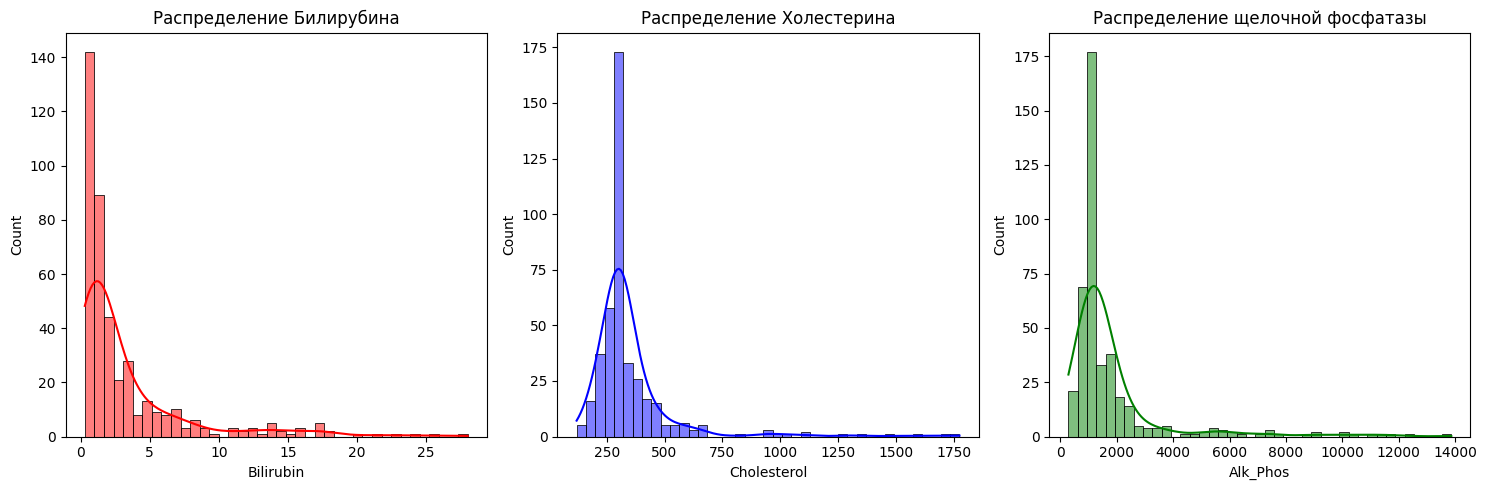

In [47]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(final_df['Bilirubin'], kde=True, color='red')
plt.title('Распределение Билирубина')
plt.subplot(1, 3, 2)
sns.histplot(final_df['Cholesterol'], kde=True, color='blue')
plt.title('Распределение Холестерина')
plt.subplot(1, 3, 3)
sns.histplot(final_df['Alk_Phos'], kde=True, color='green')
plt.title('Распределение щелочной фосфатазы')


plt.tight_layout()
plt.show()


#### Теперь видно те самые огромные хвосты. Как видим, основная часть пациентов имеет билирубин от 0.5 до ~ 7.5, а затем тянется огромный хвост из-за малочисленных пациентов с огромным показателем этого анализа. С холестерином и фосфатазой ситуация аналогичная. Асимметрия тоже теперь хорошо видна. ранее полученный skew и просто предположение по цифрам из перцентилей теперь подтверждено графически - есть явный скос вправо.

## **seaborn - Boxplot, ищем аномалии**

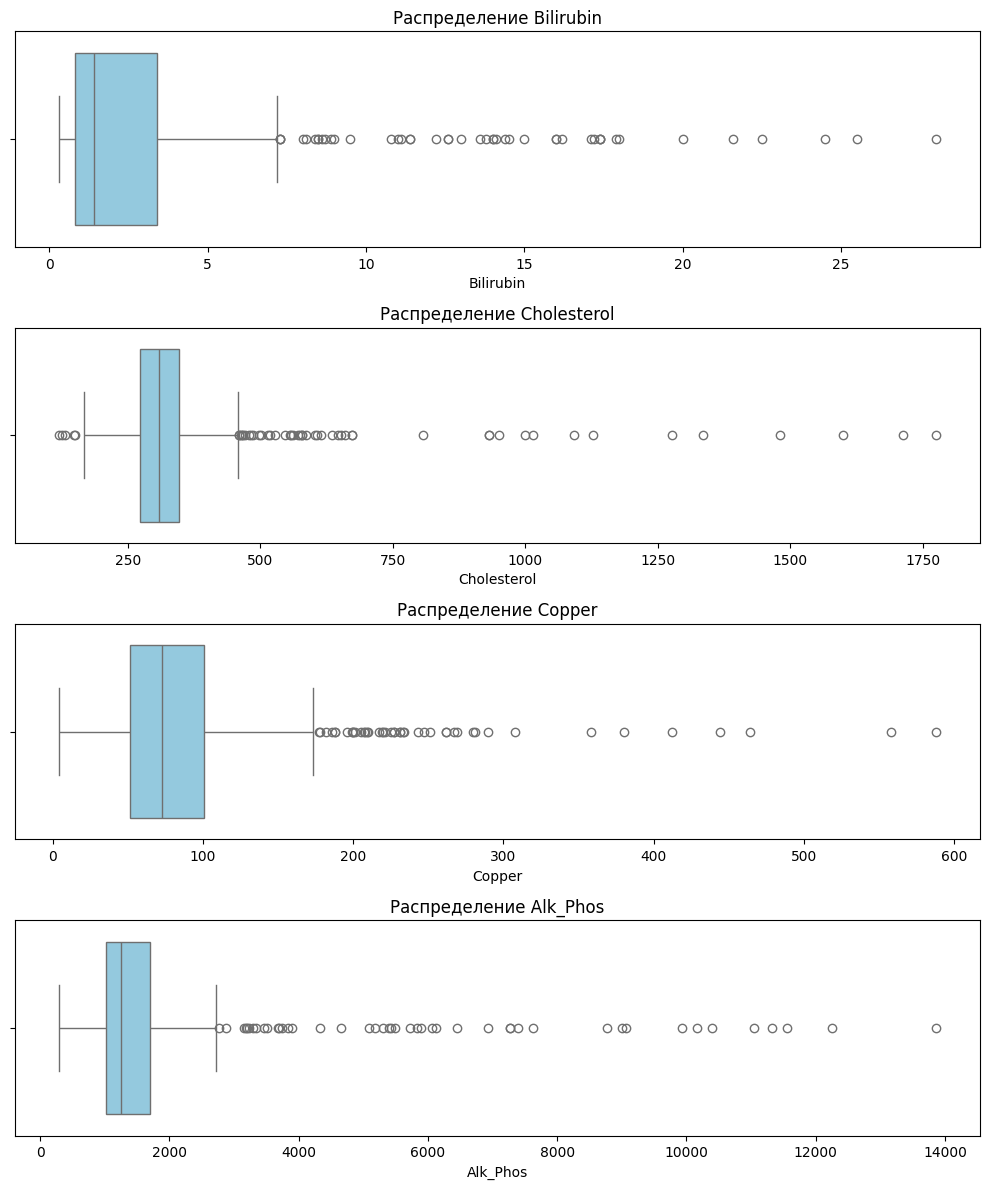

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos']

for i, col in enumerate(cols):
    sns.boxplot(x=final_df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

### В целом, это было видно и по прошлым графикам, но на boxplot аномалии в виде точек видно ещё нагляднее, квартили, изображенные коробкой дают понять, как расположена большая часть данных

## **Seaborn - scatterplot**

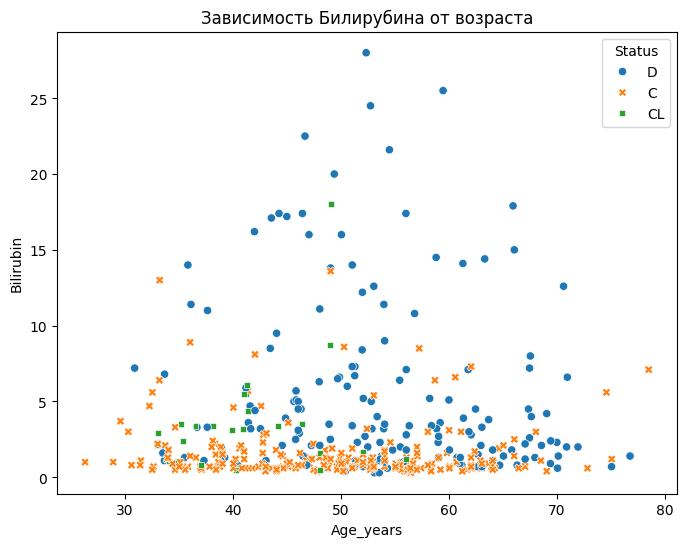

In [52]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x='Age_years', y='Bilirubin', hue='Status', style='Status')
plt.title('Зависимость Билирубина от возраста')
plt.show()

#### Этот график мне очень понравился, потому что визуально можно увидеть реальную аномалию - в почти 50 лет на показателе Bilirubin ~17 мы видим человека, который смог выжить после пересадки печени. Очень полезно, мне кажется.

## **Matplotlib - barplot**

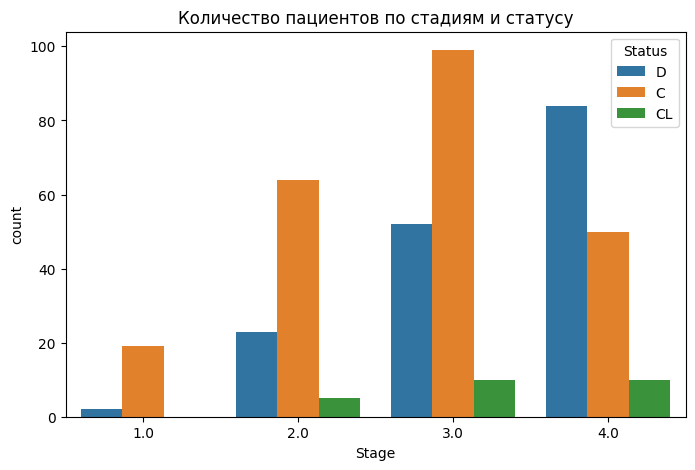

In [54]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Stage', hue='Status')
plt.title('Количество пациентов по стадиям и статусу')
plt.show()

### В целом, логично. Чем серьезнее стадия болезни, тем выше шанс умереть. ещё видим, что в нашем датасете нет случаев пересадки печени при первой стадии болезни.

## Корелляции - Seaborn

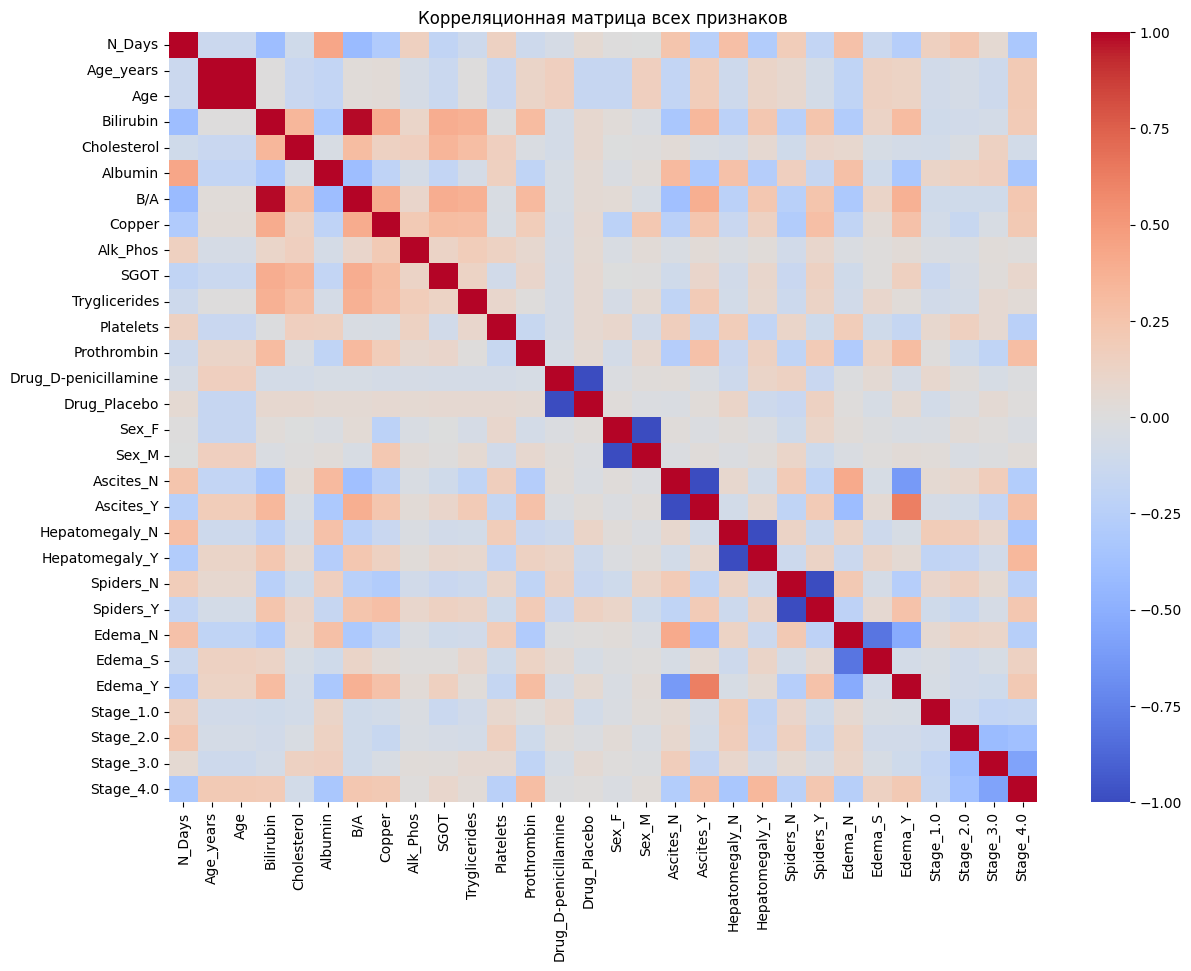

In [55]:
plt.figure(figsize=(14, 10))

numeric_cols = final_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', annot=False)
plt.title('Корреляционная матрица всех признаков')
plt.show()

### Видим синие квадратики по жиагонали - это работа onehotencoder sklearn. Можно заметить светло-оранжевую область сверху слева. Можно сделать вывод, что вся биохимия организма сыпется +- вместе из-за болезни. Интересно, что возраст очень слабо связан с биохимическими анализами.

## **Plotly интерактивчик**

In [57]:

fig = px.scatter(final_df, x="Bilirubin", y="Albumin", 
                 color="Status", 
                 hover_data=['N_Days', 'Age_years'],
                 title="Билирубин / Альбумин")
fig.show()

### Классный график, из которого можно узнать что пациент с самым огромным показателем Билирубина прожил с болезнью почти 3 года, что, кстати, больше, чем время борьбы с болезнью некоторых пациентов с менее плачевными показателями билирубина (если понаводиться, можно найти пацентов, погибших спустя 100-500 дней после регистрации.) 

# **Что я понял про датасет**

- Чаще всего категории пишут либо str, либо просто делают нумерацию. Это плохо, тк в будущем можт оказаться, что жёлтый в два раза больше, чем голубой, например.

- Зависимости могут возникать в самых неожиданных местах, для их поиска и нужно провоить EDA.

- Зависимости могут НЕ возникать в тех местах, в которых ты из ожидал, для таких опровержений и нужно проводить EDA.

- Скорее всего, перцентили 95 и 5 выбраны не просто так. Не могу заявлять по своему опыту, тк это второй датасет, но насколько я понимаю, часто 95% дисперсии создают 5% данных.

- От того, как заполнить NaN'ы напрямую зависит, правильный ли будет результат у анализа. В нашем случае, например, NaN могло означать плацебо, отсутствие лекарства или неизвестное лекарство, и мы заполнили их mean'ом, основываясь исключительно на предположении. Часто это может быть неправильным подходом.

- В больших датасетах в колонках, где много категорий, лучше всё-таки использовать энкодинг хэшированием

- Графики ОЧЕНЬ помогают понять датасет и то, что в нём происходит

- Пока я чистил датасет, я уже начинал понимать, какой у графика скос и что я хочу искать на графиках. Подозреваю, что так и должно быть при реальном EDA

## **Наблюдения / гипотезы**
- Многие признаки слабо или вообще не кореллируют ни с чем. Выкинув их, мы ничего сильно не потеряем. ***Наверное.***
- Длинные хвосты графиков - это и есть выбросы. В нашем случае выбросы - это реальные биологические показатели. Если бы это были ошибки измерений или расчётов, их можно было бы вырезать, но это именно анализы, которые могут потом у кого-то встретиться. Поэтому предполагаю, что вырезать их ***нельзя*** 
- Из первого наблюдения следует продолжение мысли - в теории если делать предсказания при помощи модели на этих данных, достаточно основных показателей, таких как Холестерин, SGOT, билирулин, медь.
- Стадия заболевания очень слабо кореллирует с показателями. У меня предположение, что это из-за того, что все анализы понемногу влияют на стадию. Либо же зависимость нелинейна. Вывод - нельзя опираться на один график, чтобы сделать какое-то глобальное суждение.

## **Какую модель я бы выбрал**
 Честно? Не знаю. Gemini сказал, что для задач с большими выбросами, которые убирать нельзя, отлично подходит XGBoost. С него бы я и начал. Когда я немного разберусь с моделями, возможно, я вернусь к этому ноутбуку и закоммичу ответ на этот вопрос.

## **Какие подсказки брал у AI**
 - Я просил ии помочь вспомнить синтаксис подзабытого python, просил оптимизировать и упростить код, разросшийся на несколько строк, если чувствовал, что можно его записать в одну, ещё и более читаемо. 
 - Объяснения терминов
 - Помощь с графиками. с ними было реально тяжко, пока не разобрался - всё ехало и слипалось.
 - ии повыписывал мне основные концепции, методы и свойства объектов из используемых библиотек.